In [19]:
# ==============================
# 1️⃣ IMPORTS
# ==============================
import os, sys, math, random, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from glob import glob
from PIL import Image
from collections import defaultdict
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    print('✓ GPU is available. Using CUDA')
else:
    print('⚠ Using CPU')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ==============================
# 2️⃣ CONFIGURATION
# ==============================
ROOT_DIR = 'kvasir-dataset-v2'  # корень датасета

# Обучение teacher linear probe
TEACHER_LR = 5e-4
TEACHER_EPOCHS = 5

# Обучение студента с контрастной дистилляцией
KD_LR = 1e-4
KD_EPOCHS = 10
BATCH_SIZE = 16
NUM_WORKERS = 0

# Гиперпараметры контрастной дистилляции
TEMPERATURE_KD = 4.0          # температура для KL divergence (логиты)
TEMPERATURE_CONTRAST = 0.07   # температура для контрастного loss
ALPHA_CONTRAST = 0.5          # вес контрастного loss
BETA_KD = 0.3                 # вес KL loss
GAMMA_CE = 0.2                # вес CE loss
PROJECTION_DIM = 256          # размерность projection space

SAVE_BEST = True

print(f'Конфигурация:')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  KD epochs: {KD_EPOCHS}')
print(f'  Loss weights: α={ALPHA_CONTRAST} (contrast), β={BETA_KD} (KD), γ={GAMMA_CE} (CE)')



✓ GPU is available. Using CUDA
Конфигурация:
  Batch size: 16
  KD epochs: 10
  Loss weights: α=0.5 (contrast), β=0.3 (KD), γ=0.2 (CE)


In [20]:
# ==============================
# 3️⃣ CONTRASTIVE LOSS (InfoNCE)
# ==============================
class ContrastiveLoss(nn.Module):
    """
    Контрастный loss для дистилляции признаков.
    Использует InfoNCE (NT-Xent) для приближения embedding'ов студента к учителю.
    
    InfoNCE формула:
    L = -log(exp(sim(z_i, z_i^+)/τ) / Σ_j exp(sim(z_i, z_j)/τ))
    
    где z_i - студент, z_i^+ - соответствующий учитель (positive),
    z_j - все остальные в батче (negatives)
    """
    def __init__(self, temperature=0.07, normalize=True):
        super().__init__()
        self.temperature = temperature
        self.normalize = normalize
        
    def forward(self, student_features, teacher_features):
        """
        Args:
            student_features: [batch_size, projection_dim]
            teacher_features: [batch_size, projection_dim]
        
        Returns:
            InfoNCE loss (scalar)
        """
        batch_size = student_features.shape[0]
        
        # L2 нормализация для cosine similarity
        if self.normalize:
            student_features = F.normalize(student_features, dim=1)
            teacher_features = F.normalize(teacher_features, dim=1)
        
        # Similarity matrix: [batch_size, batch_size]
        # similarity[i,j] = cosine_sim(student_i, teacher_j) / temperature
        similarity_matrix = torch.matmul(student_features, teacher_features.T) / self.temperature
        
        # Positive pairs находятся на диагонали
        # Каждый student_i должен быть близок к teacher_i (positive)
        # и далек от teacher_j где j≠i (negatives)
        labels = torch.arange(batch_size, device=student_features.device)
        
        # InfoNCE = Cross-Entropy с диагональными элементами как ground truth
        loss = F.cross_entropy(similarity_matrix, labels)
        
        return loss

# ==============================
# 4️⃣ COMBINED LOSS
# ==============================
class ContrastiveDistillationLoss(nn.Module):
    """
    Комбинированный loss для контрастной дистилляции:
    
    Total Loss = α·L_contrast + β·L_KD + γ·L_CE
    
    где:
    - L_contrast: InfoNCE между projected features (контрастное обучение)
    - L_KD: KL divergence между логитами учителя и студента (knowledge distillation)
    - L_CE: Cross-Entropy по ground truth меткам (классификация)
    """
    def __init__(self, temperature_kd=4.0, temperature_contrast=0.07, 
                 alpha=0.5, beta=0.3, gamma=0.2):
        super().__init__()
        self.T_kd = temperature_kd
        self.alpha = alpha  # weight for contrastive
        self.beta = beta    # weight for KD
        self.gamma = gamma  # weight for CE
        
        self.contrastive_loss = ContrastiveLoss(temperature=temperature_contrast)
        self.kl_loss = nn.KLDivLoss(reduction='batchmean')
        self.ce_loss = nn.CrossEntropyLoss()
        
    def forward(self, student_features, teacher_features, 
                student_logits, teacher_logits, labels):
        """
        Args:
            student_features: projected features from student [B, proj_dim]
            teacher_features: projected features from teacher [B, proj_dim]
            student_logits: classification logits from student [B, num_classes]
            teacher_logits: classification logits from teacher [B, num_classes]
            labels: ground truth labels [B]
        
        Returns:
            total_loss, contrast_loss, kd_loss, ce_loss
        """
        # 1. Контрастная дистилляция (InfoNCE на признаках)
        contrast_loss = self.contrastive_loss(student_features, teacher_features)
        
        # 2. Knowledge Distillation (KL на логитах с температурой)
        kd_loss = self.kl_loss(
            F.log_softmax(student_logits / self.T_kd, dim=-1),
            F.softmax(teacher_logits / self.T_kd, dim=-1)
        ) * (self.T_kd ** 2)
        
        # 3. Classification Loss (CE на ground truth)
        ce_loss = self.ce_loss(student_logits, labels)
        
        # Взвешенная сумма
        total_loss = (self.alpha * contrast_loss + 
                     self.beta * kd_loss + 
                     self.gamma * ce_loss)
        
        return total_loss, contrast_loss, kd_loss, ce_loss

# ==============================
# 5️⃣ PROJECTION HEAD
# ==============================
class ProjectionHead(nn.Module):
    """
    MLP projection head для преобразования признаков в общее пространство.
    
    Используется для контрастного обучения, чтобы:
    - Привести разные размерности teacher/student к одному projection_dim
    - Обучить нелинейное отображение для лучшего матчинга
    
    Architecture: Linear -> ReLU -> Linear
    """
    def __init__(self, input_dim, hidden_dim=512, output_dim=256):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.projection(x)



In [21]:
cd ..

c:\Users\amirn\OneDrive\Рабочий стол\ViT_opti\ViT_optimization


In [22]:
cd data

c:\Users\amirn\OneDrive\Рабочий стол\ViT_opti\ViT_optimization\data


In [23]:
# ==============================
# 6️⃣ CLASSIFICATION HEAD
# ==============================
class LinearHead(nn.Module):
    """Простая линейная голова для классификации"""
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)
    
    def forward(self, x):
        return self.fc(x)

# ==============================
# 7️⃣ DATASET PREPARATION
# ==============================
def extract_label_from_path(image_path, root_dir):
    """Извлекает метку класса из пути к файлу"""
    parts = Path(image_path).parts
    try:
        ridx = parts.index(Path(root_dir).name)
        return parts[ridx + 1]
    except (ValueError, IndexError):
        return None

print('\n' + '='*80)
print('ПОДГОТОВКА ДАТАСЕТА')
print('='*80)

print('Ищем изображения...')
all_image_paths = glob(os.path.join(ROOT_DIR, '**', '*.jpg'), recursive=True)
print(f'Найдено {len(all_image_paths)} jpg-файлов')

image_to_path, image_to_label = {}, {}
for p in all_image_paths:
    image_id = os.path.splitext(os.path.basename(p))[0]
    label = extract_label_from_path(p, ROOT_DIR)
    if label is not None:
        image_to_path[image_id] = p
        image_to_label[image_id] = label

print(f'Валидных изображений: {len(image_to_label)}')

classes = sorted(list(set(image_to_label.values())))
label_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_label = {i: c for c, i in label_to_idx.items()}
num_classes = len(classes)
print(f'Классов: {num_classes} -> {classes}')

# Сбалансированное подмножество
images_by_class = defaultdict(list)
for img_id, lbl in image_to_label.items():
    images_by_class[lbl].append(img_id)

images_per_class = 500
sampled = []
for lbl, ids in images_by_class.items():
    k = min(images_per_class, len(ids))
    sampled.extend(random.sample(ids, k))
random.shuffle(sampled)
print(f'Подмножество: {len(sampled)} изображений')




ПОДГОТОВКА ДАТАСЕТА
Ищем изображения...
Найдено 8000 jpg-файлов
Валидных изображений: 7999
Классов: 8 -> ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
Подмножество: 4000 изображений


In [24]:
# Train/Val/Test split
labels_for_strat = [image_to_label[i] for i in sampled]
train_val_ids, test_ids = train_test_split(sampled, test_size=0.20, stratify=labels_for_strat, random_state=SEED)
train_labels_for_strat = [image_to_label[i] for i in train_val_ids]
train_ids, val_ids = train_test_split(train_val_ids, test_size=0.20, stratify=train_labels_for_strat, random_state=SEED)

print(f'Split: Train={len(train_ids)}  Val={len(val_ids)}  Test={len(test_ids)}')

# ==============================
# 8️⃣ DATASET CLASS
# ==============================
class KDDataset(Dataset):
    """
    Dataset для контрастной дистилляции.
    Возвращает два преобразованных изображения (для teacher и student) + метку.
    """
    def __init__(self, image_ids, image_to_path, image_to_label, label_to_idx, 
                 teacher_transform, student_transform):
        self.ids = image_ids
        self.image_to_path = image_to_path
        self.image_to_label = image_to_label
        self.label_to_idx = label_to_idx
        self.t_transform = teacher_transform
        self.s_transform = student_transform
    
    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        path = self.image_to_path[img_id]
        label = self.image_to_label[img_id]
        y = self.label_to_idx[label]
        
        img = Image.open(path).convert('RGB')
        x_teacher = self.t_transform(img)
        x_student = self.s_transform(img)
        
        return x_teacher, x_student, torch.tensor(y, dtype=torch.long)


Split: Train=2560  Val=640  Test=800


In [25]:
# ==============================
# 9️⃣ MODEL LOADING
# ==============================
print('\n' + '='*80)
print('ЗАГРУЗКА МОДЕЛЕЙ')
print('='*80)

# Переход в директорию с моделями
os.chdir('..')
os.chdir('perception_models')

from core.vision_encoder import pe
from core.vision_encoder import transforms

print('Загружаем учителя: PE-Core-L14-336...')
teacher_model = pe.CLIP.from_config('PE-Core-L14-336', pretrained=True).to(device).float()
teacher_model.eval()

print('Загружаем студента: PE-Core-S16-384...')
student_model = pe.CLIP.from_config('PE-Core-S16-384', pretrained=True).to(device).float()

teacher_preprocessor = transforms.get_image_transform(teacher_model.image_size)
student_preprocessor = transforms.get_image_transform(student_model.image_size)

teacher_dim = teacher_model.visual.output_dim
student_dim = student_model.visual.output_dim

print(f'✓ Модели загружены')
print(f'  Teacher: image_size={teacher_model.image_size}, dim={teacher_dim}')
print(f'  Student: image_size={student_model.image_size}, dim={student_dim}')


ЗАГРУЗКА МОДЕЛЕЙ
Загружаем учителя: PE-Core-L14-336...
Missing keys for loading model: []
Unexpected keys for loading model: []
Загружаем студента: PE-Core-S16-384...
Missing keys for loading model: []
Unexpected keys for loading model: []
✓ Модели загружены
  Teacher: image_size=336, dim=1024
  Student: image_size=384, dim=512


In [26]:
# Возврат в data директорию
os.chdir('..')
os.chdir('data')

# ==============================
# 🔟 DATALOADERS
# ==============================
train_ds = KDDataset(train_ids, image_to_path, image_to_label, label_to_idx, 
                     teacher_preprocessor, student_preprocessor)
val_ds = KDDataset(val_ids, image_to_path, image_to_label, label_to_idx, 
                   teacher_preprocessor, student_preprocessor)
test_ds = KDDataset(test_ids, image_to_path, image_to_label, label_to_idx, 
                    teacher_preprocessor, student_preprocessor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('✓ DataLoaders готовы')

# ==============================
# 1️⃣1️⃣ INITIALIZE HEADS
# ==============================
print('\n' + '='*80)
print('ИНИЦИАЛИЗАЦИЯ ГОЛОВ')
print('='*80)

# Classification heads
teacher_head = LinearHead(teacher_dim, num_classes).to(device)
student_head = LinearHead(student_dim, num_classes).to(device)

# Projection heads для контрастного обучения
teacher_projection = ProjectionHead(teacher_dim, hidden_dim=512, output_dim=PROJECTION_DIM).to(device)
student_projection = ProjectionHead(student_dim, hidden_dim=512, output_dim=PROJECTION_DIM).to(device)

print(f'✓ Classification heads: {teacher_dim}/{student_dim} -> {num_classes}')
print(f'✓ Projection heads: {teacher_dim}/{student_dim} -> {PROJECTION_DIM}')

# ==============================
# 1️⃣2️⃣ TRAIN TEACHER LINEAR PROBE
# ==============================
print('\n' + '='*80)
print('ОБУЧЕНИЕ TEACHER LINEAR PROBE')
print('='*80)

def evaluate_head(model, head, loader, device):
    """Оценка accuracy линейной головы"""
    model.eval()
    head.eval()
    correct, total, loss_sum, n_batches = 0, 0, 0.0, 0
    ce = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for x_t, _, y in loader:
            x_t = x_t.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            
            feats = model.encode_image(x_t)
            logits = head(feats)
            loss = ce(logits, y)
            
            _, pred = torch.max(logits, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
            loss_sum += loss.item()
            n_batches += 1
    
    acc = 100.0 * correct / total if total > 0 else 0.0
    return (loss_sum / max(1, n_batches)), acc

def train_teacher_probe(model, head, train_loader, val_loader, epochs, lr):
    """Обучение линейной головы учителя (энкодер заморожен)"""
    # Замораживаем энкодер
    for p in model.parameters():
        p.requires_grad = False
    
    head.train()
    optimizer = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=1e-5)
    ce = nn.CrossEntropyLoss()
    
    best_val_acc = -1.0
    best_state = None
    
    for ep in range(1, epochs + 1):
        head.train()
        loss_sum, n_batches, correct, total = 0.0, 0, 0, 0
        
        for x_t, _, y in train_loader:
            x_t = x_t.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            
            with torch.no_grad():
                feats = model.encode_image(x_t)
            
            logits = head(feats)
            loss = ce(logits, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, pred = torch.max(logits, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
            loss_sum += loss.item()
            n_batches += 1
        
        train_acc = 100.0 * correct / total if total > 0 else 0.0
        val_loss, val_acc = evaluate_head(model, head, val_loader, device)
        
        print(f'Epoch {ep}/{epochs} | TrainAcc={train_acc:.2f}% | ValAcc={val_acc:.2f}% | ValLoss={val_loss:.4f}')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = head.state_dict()
    
    # Загружаем лучшее состояние
    if best_state is not None:
        head.load_state_dict(best_state)
    
    # Замораживаем голову
    for p in head.parameters():
        p.requires_grad = False
    head.eval()
    
    torch.save({'state_dict': head.state_dict(), 'num_classes': num_classes}, 
               '../model_weights/Contrastive_S_teacher_linear_probe.pth')
    print(f'✓ Teacher probe сохранен (лучшая ValAcc={best_val_acc:.2f}%)')
    
    return best_val_acc



✓ DataLoaders готовы

ИНИЦИАЛИЗАЦИЯ ГОЛОВ
✓ Classification heads: 1024/512 -> 8
✓ Projection heads: 1024/512 -> 256

ОБУЧЕНИЕ TEACHER LINEAR PROBE


In [27]:
# Обучаем teacher probe
teacher_val_acc = train_teacher_probe(teacher_model, teacher_head, 
                                      train_loader, val_loader, 
                                      TEACHER_EPOCHS, TEACHER_LR)

Epoch 1/5 | TrainAcc=70.16% | ValAcc=84.38% | ValLoss=0.6233
Epoch 2/5 | TrainAcc=85.04% | ValAcc=87.19% | ValLoss=0.4564
Epoch 3/5 | TrainAcc=87.27% | ValAcc=86.56% | ValLoss=0.4321
Epoch 4/5 | TrainAcc=88.48% | ValAcc=88.59% | ValLoss=0.3390
Epoch 5/5 | TrainAcc=89.41% | ValAcc=89.84% | ValLoss=0.3196
✓ Teacher probe сохранен (лучшая ValAcc=89.84%)


In [28]:


# ==============================
# 1️⃣3️⃣ INITIALIZE CONTRASTIVE DISTILLATION
# ==============================
print('\n' + '='*80)
print('ИНИЦИАЛИЗАЦИЯ КОНТРАСТНОЙ ДИСТИЛЛЯЦИИ')
print('='*80)

# Loss function
criterion = ContrastiveDistillationLoss(
    temperature_kd=TEMPERATURE_KD,
    temperature_contrast=TEMPERATURE_CONTRAST,
    alpha=ALPHA_CONTRAST,
    beta=BETA_KD,
    gamma=GAMMA_CE
)

# Optimizer (обучаем студента + его головы)
# Teacher остается замороженным
for p in teacher_model.parameters():
    p.requires_grad = False
for p in teacher_head.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    list(student_model.parameters()) + 
    list(student_head.parameters()) + 
    list(student_projection.parameters()) +
    list(teacher_projection.parameters()),  # можно заморозить, но обычно обучают
    lr=KD_LR, 
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=KD_EPOCHS)

print('✓ Loss, optimizer, scheduler инициализированы')
print(f'  Learning rate: {KD_LR}')
print(f'  Scheduler: CosineAnnealing (T_max={KD_EPOCHS})')


ИНИЦИАЛИЗАЦИЯ КОНТРАСТНОЙ ДИСТИЛЛЯЦИИ
✓ Loss, optimizer, scheduler инициализированы
  Learning rate: 0.0001
  Scheduler: CosineAnnealing (T_max=10)


In [29]:
# ==============================
# 1️⃣4️⃣ VALIDATION FUNCTION
# ==============================
def validate_contrastive(teacher_model, student_model,
                         teacher_head, student_head,
                         teacher_projection, student_projection,
                         loader, criterion, device):
    """Валидация студента с контрастной дистилляцией"""
    teacher_model.eval()
    student_model.eval()
    teacher_head.eval()
    student_head.eval()
    teacher_projection.eval()
    student_projection.eval()
    
    total_loss = total_contrast = total_kd = total_ce = 0.0
    correct = total = n_batches = 0
    
    with torch.no_grad():
        for x_t, x_s, y in loader:
            x_t = x_t.to(device, non_blocking=True)
            x_s = x_s.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            
            # Teacher forward
            t_features = teacher_model.encode_image(x_t)
            t_projected = teacher_projection(t_features)
            t_logits = teacher_head(t_features)
            
            # Student forward
            s_features = student_model.encode_image(x_s)
            s_projected = student_projection(s_features)
            s_logits = student_head(s_features)
            
            # Loss calculation
            loss, contrast, kd, ce = criterion(
                s_projected, t_projected,
                s_logits, t_logits, y
            )
            
            total_loss += loss.item()
            total_contrast += contrast.item()
            total_kd += kd.item()
            total_ce += ce.item()
            
            _, pred = torch.max(s_logits, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
            n_batches += 1
    
    avg_loss = total_loss / max(1, n_batches)
    avg_contrast = total_contrast / max(1, n_batches)
    avg_kd = total_kd / max(1, n_batches)
    avg_ce = total_ce / max(1, n_batches)
    acc = 100.0 * correct / total if total > 0 else 0.0
    
    return avg_loss, avg_contrast, avg_kd, avg_ce, acc


In [30]:
import sys
import os

# ==============================
# VALIDATION FUNCTION
# ==============================
def validate_contrastive(teacher_model, student_model,
                         teacher_head, student_head,
                         teacher_projection, student_projection,
                         loader, criterion, device):
    """Валидация студента с контрастной дистилляцией"""
    teacher_model.eval()
    student_model.eval()
    teacher_head.eval()
    student_head.eval()
    teacher_projection.eval()
    student_projection.eval()
    
    total_loss = total_contrast = total_kd = total_ce = 0.0
    correct = total = n_batches = 0
    
    with torch.no_grad():
        for x_t, x_s, y in loader:
            x_t = x_t.to(device, non_blocking=True)
            x_s = x_s.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            
            # Teacher forward
            t_features = teacher_model.encode_image(x_t)
            t_projected = teacher_projection(t_features)
            t_logits = teacher_head(t_features)
            
            # Student forward
            s_features = student_model.encode_image(x_s)
            s_projected = student_projection(s_features)
            s_logits = student_head(s_features)
            
            # Loss calculation
            loss, contrast, kd, ce = criterion(
                s_projected, t_projected,
                s_logits, t_logits, y
            )
            
            total_loss += loss.item()
            total_contrast += contrast.item()
            total_kd += kd.item()
            total_ce += ce.item()
            
            _, pred = torch.max(s_logits, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
            n_batches += 1
    
    avg_loss = total_loss / max(1, n_batches)
    avg_contrast = total_contrast / max(1, n_batches)
    avg_kd = total_kd / max(1, n_batches)
    avg_ce = total_ce / max(1, n_batches)
    acc = 100.0 * correct / total if total > 0 else 0.0
    
    return avg_loss, avg_contrast, avg_kd, avg_ce, acc

# ==============================
# TRAINING FUNCTION
# ==============================
def train_contrastive_distillation(teacher_model, student_model, 
                                   teacher_head, student_head,
                                   teacher_projection, student_projection,
                                   train_loader, val_loader, 
                                   criterion, optimizer, scheduler,
                                   epochs, device):
    """Основной цикл обучения с контрастной дистилляцией (с периодическим выводом)."""
    history = {
        'train_loss': [], 'train_contrast': [], 'train_kd': [], 'train_ce': [],
        'val_loss': [], 'val_contrast': [], 'val_kd': [], 'val_ce': [], 'val_acc': []
    }

    best_val_acc = -1.0
    best_state = None

    print('\n' + '='*80, flush=True)
    print('НАЧАЛО ОБУЧЕНИЯ С КОНТРАСТНОЙ ДИСТИЛЛЯЦИЕЙ', flush=True)
    print('='*80 + '\n', flush=True)

    # защита: пустой даталоадер
    if len(train_loader) == 0:
        print('⚠ train_loader пустой — прекращаю обучение', flush=True)
        return history, best_val_acc

    os.makedirs('../model_weights', exist_ok=True)
    
    total_batches = len(train_loader)
    print_every = max(1, total_batches // 10)  # печать ~10 раз за эпоху

    for epoch in range(1, epochs + 1):
        # режимы
        student_model.train()
        student_head.train()
        student_projection.train()
        teacher_model.eval()
        teacher_head.eval()
        teacher_projection.train()

        loss_sum = contrast_sum = kd_sum = ce_sum = 0.0
        n_batches = 0

        print(f'\n📍 Epoch {epoch}/{epochs} | Batches: {total_batches}', flush=True)

        try:
            for batch_idx, (x_t, x_s, y) in enumerate(train_loader):
                x_t = x_t.to(device, non_blocking=True)
                x_s = x_s.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)

                # Teacher forward (encoder frozen)
                with torch.no_grad():
                    t_features = teacher_model.encode_image(x_t)
                    t_logits = teacher_head(t_features)

                t_projected = teacher_projection(t_features)

                # Student forward
                s_features = student_model.encode_image(x_s)
                s_projected = student_projection(s_features)
                s_logits = student_head(s_features)

                total_loss, contrast_loss, kd_loss, ce_loss = criterion(
                    s_projected, t_projected,
                    s_logits, t_logits, y
                )

                optimizer.zero_grad()
                total_loss.backward()
                optimizer.step()

                loss_sum += total_loss.item()
                contrast_sum += contrast_loss.item()
                kd_sum += kd_loss.item()
                ce_sum += ce_loss.item()
                n_batches += 1

                # Периодический вывод прогресса
                if (batch_idx + 1) % print_every == 0 or (batch_idx + 1) == total_batches:
                    avg_loss = loss_sum / n_batches
                    progress = 100.0 * (batch_idx + 1) / total_batches
                    print(f'  [{epoch}] {batch_idx+1}/{total_batches} ({progress:.1f}%) | loss={avg_loss:.4f}', flush=True)
                    sys.stdout.flush()

        except KeyboardInterrupt:
            print('\n⏹️ Прервано пользователем. Сохраняю лучший чекпоинт (если есть)...', flush=True)
            if best_state is not None:
                torch.save(best_state, '../model_weights/Contrastive_S_student_best.pth')
            raise

        avg_train_loss = loss_sum / max(1, n_batches)
        avg_train_contrast = contrast_sum / max(1, n_batches)
        avg_train_kd = kd_sum / max(1, n_batches)
        avg_train_ce = ce_sum / max(1, n_batches)

        # Валидация
        print(f'  Валидация...', flush=True)
        val_loss, val_contrast, val_kd, val_ce, val_acc = validate_contrastive(
            teacher_model, student_model,
            teacher_head, student_head,
            teacher_projection, student_projection,
            val_loader, criterion, device
        )

        # шаг шедулера
        try:
            scheduler.step()
        except Exception:
            pass

        # история
        history['train_loss'].append(avg_train_loss)
        history['train_contrast'].append(avg_train_contrast)
        history['train_kd'].append(avg_train_kd)
        history['train_ce'].append(avg_train_ce)
        history['val_loss'].append(val_loss)
        history['val_contrast'].append(val_contrast)
        history['val_kd'].append(val_kd)
        history['val_ce'].append(val_ce)
        history['val_acc'].append(val_acc)

        # печать итогов эпохи
        print(f'\n✅ Epoch {epoch}/{epochs} завершена:', flush=True)
        print(f'  Train: loss={avg_train_loss:.4f} | contrast={avg_train_contrast:.4f} | kd={avg_train_kd:.4f} | ce={avg_train_ce:.4f}', flush=True)
        print(f'  Val:   loss={val_loss:.4f} | contrast={val_contrast:.4f} | kd={val_kd:.4f} | ce={val_ce:.4f} | acc={val_acc:.2f}%', flush=True)

        # Сохраняем лучшую модель
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {
                'student_model': student_model.state_dict(),
                'student_head': student_head.state_dict(),
                'student_projection': student_projection.state_dict(),
                'teacher_projection': teacher_projection.state_dict(),
                'epoch': epoch,
                'val_acc': val_acc,
                'config': {
                    'temperature_kd': TEMPERATURE_KD,
                    'temperature_contrast': TEMPERATURE_CONTRAST,
                    'alpha': ALPHA_CONTRAST,
                    'beta': BETA_KD,
                    'gamma': GAMMA_CE,
                    'projection_dim': PROJECTION_DIM
                }
            }
            torch.save(best_state, '../model_weights/Contrastive_S_student_best.pth')
            print(f'  🎯 Сохранена новая лучшая модель (ValAcc={val_acc:.2f}%)', flush=True)

    print(f'\n🏁 Обучение завершено! Лучшая ValAcc: {best_val_acc:.2f}%', flush=True)
    return history, best_val_acc

# ==============================
# START TRAINING
# ==============================
history, best_val_acc = train_contrastive_distillation(
    teacher_model, student_model,
    teacher_head, student_head,
    teacher_projection, student_projection,
    train_loader, val_loader,
    criterion, optimizer, scheduler,
    KD_EPOCHS, device
)


НАЧАЛО ОБУЧЕНИЯ С КОНТРАСТНОЙ ДИСТИЛЛЯЦИЕЙ


📍 Epoch 1/10 | Batches: 160
  [1] 16/160 (10.0%) | loss=2.5544
  [1] 32/160 (20.0%) | loss=2.0368
  [1] 48/160 (30.0%) | loss=1.7627
  [1] 64/160 (40.0%) | loss=1.5968
  [1] 80/160 (50.0%) | loss=1.4814
  [1] 96/160 (60.0%) | loss=1.4084
  [1] 112/160 (70.0%) | loss=1.3355
  [1] 128/160 (80.0%) | loss=1.2792
  [1] 144/160 (90.0%) | loss=1.2269
  [1] 160/160 (100.0%) | loss=1.1732
  Валидация...

✅ Epoch 1/10 завершена:
  Train: loss=1.1732 | contrast=1.2753 | kd=1.2500 | ce=0.8027
  Val:   loss=0.7419 | contrast=0.8289 | kd=0.7186 | ce=0.5593 | acc=75.00%
  🎯 Сохранена новая лучшая модель (ValAcc=75.00%)

📍 Epoch 2/10 | Batches: 160
  [2] 16/160 (10.0%) | loss=0.6164
  [2] 32/160 (20.0%) | loss=0.6088
  [2] 48/160 (30.0%) | loss=0.6043
  [2] 64/160 (40.0%) | loss=0.5902
  [2] 80/160 (50.0%) | loss=0.5892
  [2] 96/160 (60.0%) | loss=0.5741
  [2] 112/160 (70.0%) | loss=0.5653
  [2] 128/160 (80.0%) | loss=0.5662
  [2] 144/160 (90.0%) | loss=0.

KeyboardInterrupt: 

In [17]:
# ==============================
# 1️⃣7️⃣ TESTING
# ==============================
print('\n' + '='*80)
print('ТЕСТИРОВАНИЕ')
print('='*80)

def test_student(student_model, student_head, loader, device):
    """Финальное тестирование студента"""
    student_model.eval()
    student_head.eval()
    correct, total = 0, 0
    class_correct = defaultdict(int)
    class_total = defaultdict(int)
    
    with torch.no_grad():
        for _, x_s, y in loader:
            x_s = x_s.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            
            s_feat = student_model.encode_image(x_s)
            logits = student_head(s_feat)
            _, pred = torch.max(logits, 1)
            
            total += y.size(0)
            correct += (pred == y).sum().item()
            
            for i in range(y.size(0)):
                cls_name = idx_to_label[y[i].item()]
                class_total[cls_name] += 1
                if pred[i] == y[i]:
                    class_correct[cls_name] += 1
    
    acc = 100.0 * correct / total if total > 0 else 0.0
    return acc, class_correct, class_total

test_acc, class_correct, class_total = test_student(student_model, student_head, test_loader, device)

print(f'\n📊 Test Accuracy: {test_acc:.2f}%')
print('\nAccuracy по классам:')
for cls in sorted(class_total.keys()):
    acc_c = 100.0 * class_correct[cls] / class_total[cls] if class_total[cls] > 0 else 0.0
    print(f'  {cls}: {acc_c:.2f}% ({class_correct[cls]}/{class_total[cls]})')

# Сохранение финальной модели
torch.save({
    'student_model': student_model.state_dict(),
    'student_head': student_head.state_dict(),
    'student_projection': student_projection.state_dict(),
    'teacher_projection': teacher_projection.state_dict(),
    'classes': classes,
    'label_to_idx': label_to_idx,
    'idx_to_label': idx_to_label,
    'teacher_dim': teacher_dim,
    'student_dim': student_dim,
    'num_classes': num_classes,
    'projection_dim': PROJECTION_DIM,
    'history': history,
    'test_acc': test_acc
}, '../model_weights/Contrastive_S_student_final.pth')
print('\n✓ Финальная модель сохранена: Contrastive_S_student_final.pth')


ТЕСТИРОВАНИЕ

📊 Test Accuracy: 93.50%

Accuracy по классам:
  dyed-lifted-polyps: 95.00% (95/100)
  dyed-resection-margins: 96.00% (96/100)
  esophagitis: 87.00% (87/100)
  normal-cecum: 95.00% (95/100)
  normal-pylorus: 98.00% (98/100)
  normal-z-line: 86.00% (86/100)
  polyps: 95.00% (95/100)
  ulcerative-colitis: 96.00% (96/100)

✓ Финальная модель сохранена: Contrastive_S_student_final.pth



ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
📈 График сохранен: contrastive_distillation_results.png


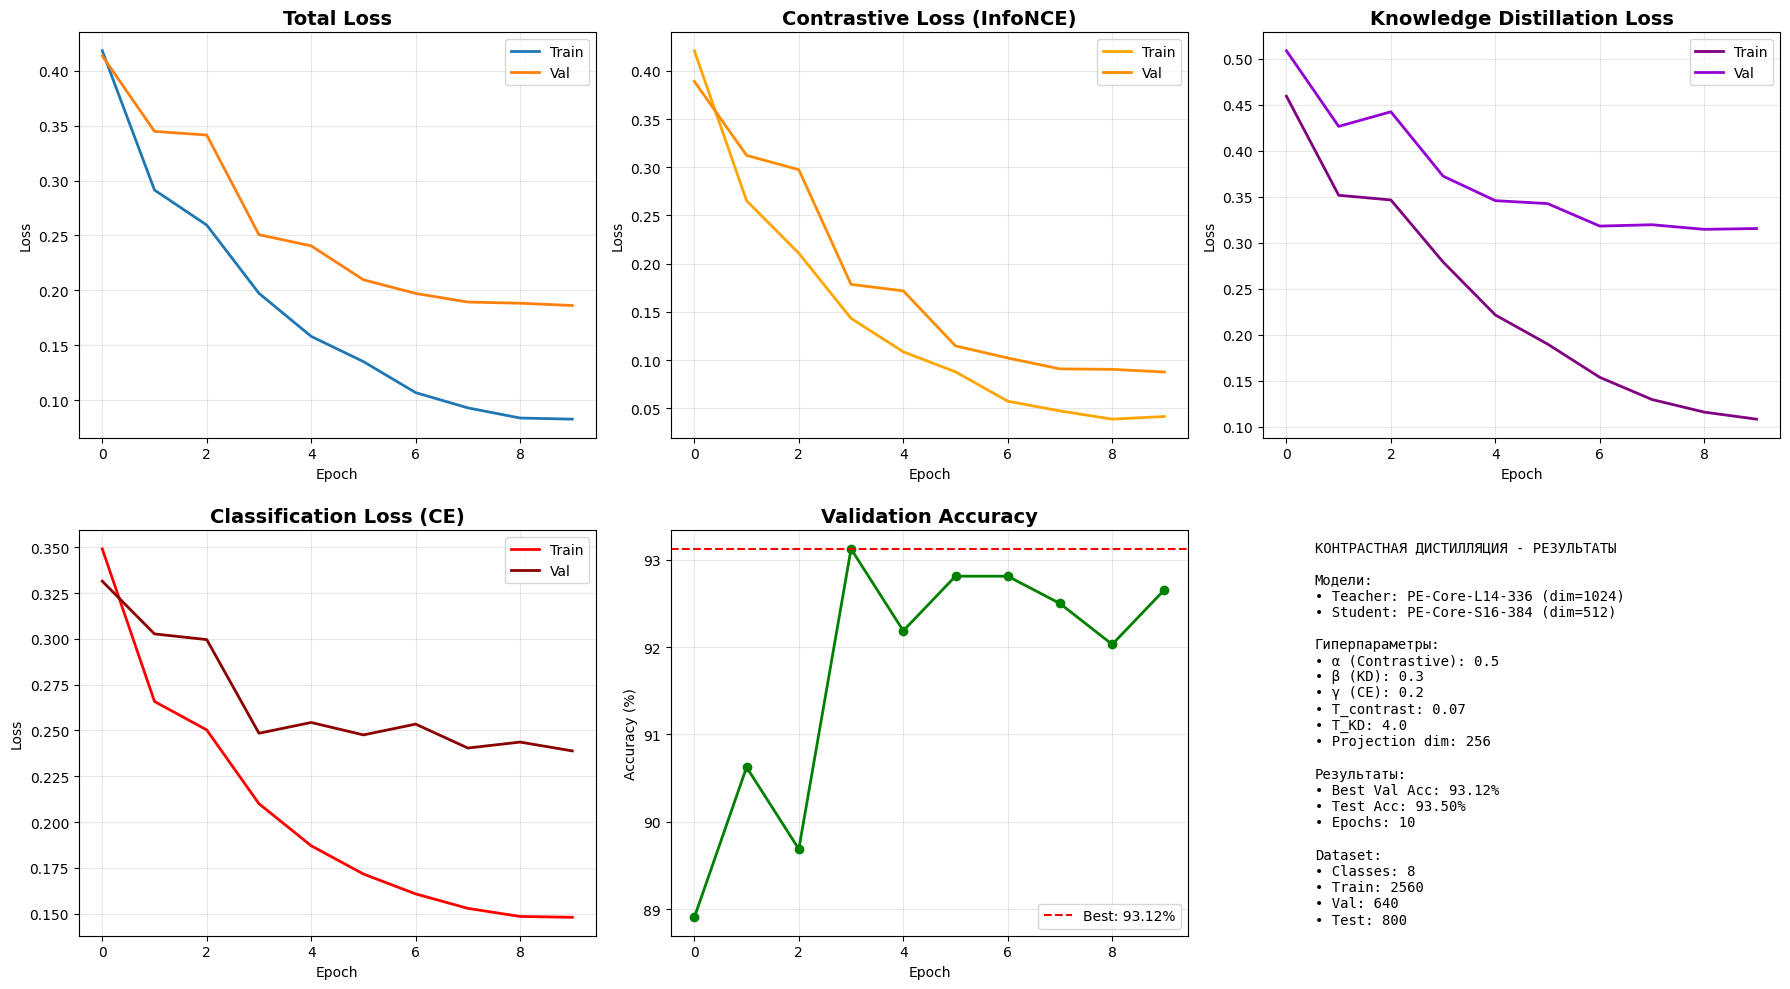


СРАВНЕНИЕ МЕТОДОВ

Таблица сравнения:
--------------------------------------------------------------------------------
Teacher (frozen)               | Val: 89.84%     | Test: -          | Dim: 1024
Student (contrastive KD)       | Val: 93.12%     | Test: 93.50%     | Dim: 512
--------------------------------------------------------------------------------

✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!

Файлы сохранены:
  • student_contrastive_best.pth - лучшая модель
  • student_contrastive_final.pth - финальная модель
  • teacher_linear_probe_contrastive.pth - teacher probe
  • contrastive_distillation_results.png - графики


In [18]:
# ==============================
# 1️⃣8️⃣ VISUALIZATION
# ==============================
print('\n' + '='*80)
print('ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ')
print('='*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Total Loss
axes[0,0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0,0].plot(history['val_loss'], label='Val', linewidth=2)
axes[0,0].set_title('Total Loss', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Contrastive Loss (InfoNCE)
axes[0,1].plot(history['train_contrast'], label='Train', linewidth=2, color='orange')
axes[0,1].plot(history['val_contrast'], label='Val', linewidth=2, color='darkorange')
axes[0,1].set_title('Contrastive Loss (InfoNCE)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# KD Loss
axes[0,2].plot(history['train_kd'], label='Train', linewidth=2, color='purple')
axes[0,2].plot(history['val_kd'], label='Val', linewidth=2, color='darkviolet')
axes[0,2].set_title('Knowledge Distillation Loss', fontsize=14, fontweight='bold')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Loss')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# CE Loss
axes[1,0].plot(history['train_ce'], label='Train', linewidth=2, color='red')
axes[1,0].plot(history['val_ce'], label='Val', linewidth=2, color='darkred')
axes[1,0].set_title('Classification Loss (CE)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Validation Accuracy
axes[1,1].plot(history['val_acc'], linewidth=2, color='green', marker='o')
axes[1,1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].axhline(y=best_val_acc, color='red', linestyle='--', label=f'Best: {best_val_acc:.2f}%')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Summary text
summary_text = f"""
КОНТРАСТНАЯ ДИСТИЛЛЯЦИЯ - РЕЗУЛЬТАТЫ

Модели:
• Teacher: PE-Core-L14-336 (dim={teacher_dim})
• Student: PE-Core-S16-384 (dim={student_dim})

Гиперпараметры:
• α (Contrastive): {ALPHA_CONTRAST}
• β (KD): {BETA_KD}
• γ (CE): {GAMMA_CE}
• T_contrast: {TEMPERATURE_CONTRAST}
• T_KD: {TEMPERATURE_KD}
• Projection dim: {PROJECTION_DIM}

Результаты:
• Best Val Acc: {best_val_acc:.2f}%
• Test Acc: {test_acc:.2f}%
• Epochs: {KD_EPOCHS}

Dataset:
• Classes: {num_classes}
• Train: {len(train_ids)}
• Val: {len(val_ids)}
• Test: {len(test_ids)}
"""
axes[1,2].text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center', family='monospace')
axes[1,2].axis('off')

plt.tight_layout()
plt.savefig('contrastive_distillation_results.png', dpi=150, bbox_inches='tight')
print('📈 График сохранен: contrastive_distillation_results.png')
plt.show()

# ==============================
# 1️⃣9️⃣ COMPARISON WITH BASELINES
# ==============================
print('\n' + '='*80)
print('СРАВНЕНИЕ МЕТОДОВ')
print('='*80)

comparison_data = {
    'Method': ['Teacher (frozen)', 'Student (contrastive KD)'],
    'Val Accuracy': [f'{teacher_val_acc:.2f}%', f'{best_val_acc:.2f}%'],
    'Test Accuracy': ['-', f'{test_acc:.2f}%'],
    'Model Size': ['Large (L14-336)', 'Small (S16-384)'],
    'Feature Dim': [teacher_dim, student_dim]
}

print('\nТаблица сравнения:')
print('-' * 80)
for i in range(len(comparison_data['Method'])):
    print(f"{comparison_data['Method'][i]:30} | Val: {comparison_data['Val Accuracy'][i]:10} | "
          f"Test: {comparison_data['Test Accuracy'][i]:10} | Dim: {comparison_data['Feature Dim'][i]}")
print('-' * 80)

print('\n✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!')
print(f'\nФайлы сохранены:')
print(f'  • student_contrastive_best.pth - лучшая модель')
print(f'  • student_contrastive_final.pth - финальная модель')
print(f'  • teacher_linear_probe_contrastive.pth - teacher probe')
print(f'  • contrastive_distillation_results.png - графики')